In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar dataset Titanic desde seaborn
df = sns.load_dataset("titanic")

# Mostrar primeras filas
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Dimensiones del dataset
df.shape

# Información general
df.info()

# Estadísticas descriptivas de variables numéricas
df.describe()

# Estadísticas descriptivas de variables categóricas
df.describe(include='object')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [5]:
# Copia del dataset original
df_clean = df.copy()

# Eliminar columnas irrelevantes para el análisis
cols_to_drop = ['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male']
df_clean = df_clean.drop(columns=cols_to_drop)

# Imputar valores faltantes
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
df_clean['fare'] = df_clean['fare'].fillna(df_clean['fare'].median())

# Eliminar filas restantes con nulos (si queda alguna)
df_clean = df_clean.dropna()

# Renombrar columnas para mayor claridad
df_clean = df_clean.rename(columns={
    'pclass': 'class',
    'sibsp': 'siblings_spouses',
    'parch': 'parents_children'
})

# Mostrar primeras filas del dataset limpio
df_clean.head()


,survived,class,sex,age,siblings_spouses,parents_children,fare,embarked,alone
0,0,3,male,22.0,1,0,7.2500,S,False
1,1,1,female,38.0,1,0,71.2833,C,False
2,1,3,female,26.0,0,0,7.9250,S,True
3,1,1,female,35.0,1,0,53.1000,S,False
4,0,3,male,35.0,0,0,8.0500,S,True


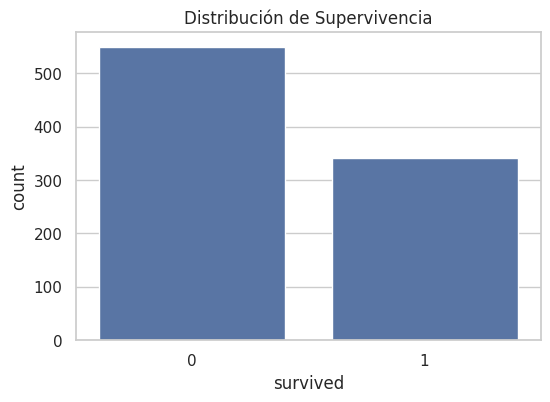

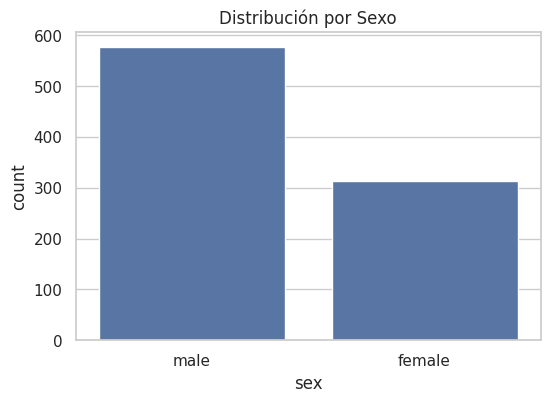

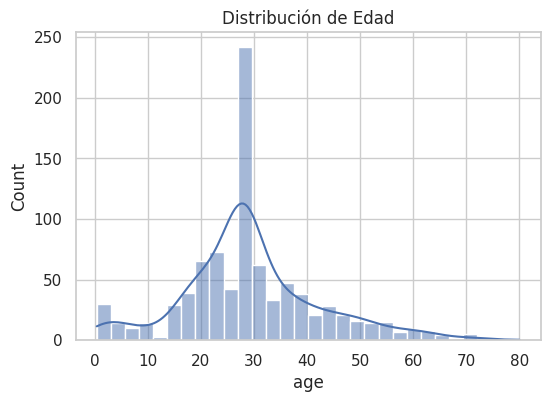

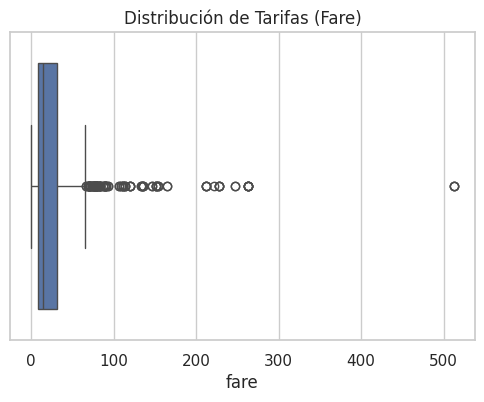

In [6]:
# Configuración de estilo
sns.set(style="whitegrid")

# --- Distribución de supervivencia ---
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='survived')
plt.title('Distribución de Supervivencia')
plt.show()

# --- Distribución por sexo ---
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='sex')
plt.title('Distribución por Sexo')
plt.show()

# --- Histograma de edades ---
plt.figure(figsize=(6,4))
sns.histplot(data=df_clean, x='age', bins=30, kde=True)
plt.title('Distribución de Edad')
plt.show()

# --- Boxplot de tarifas ---
plt.figure(figsize=(6,4))
sns.boxplot(data=df_clean, x='fare')
plt.title('Distribución de Tarifas (Fare)')
plt.show()


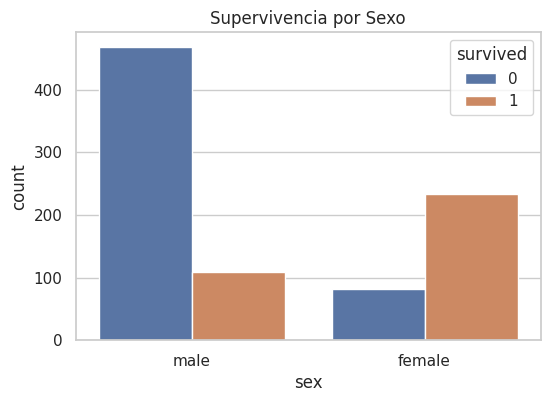

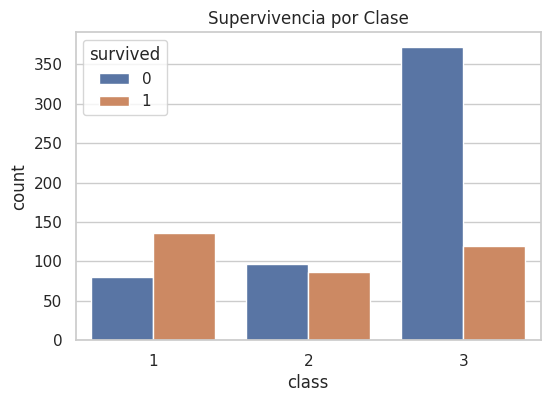

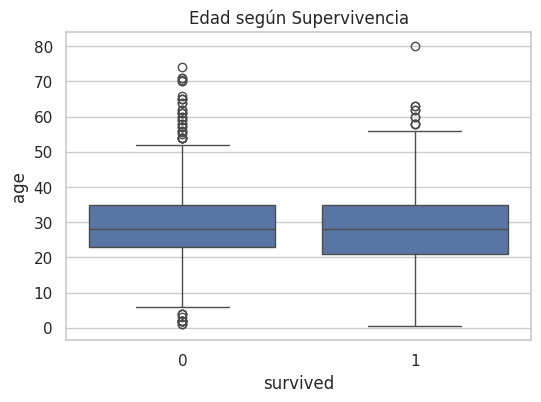

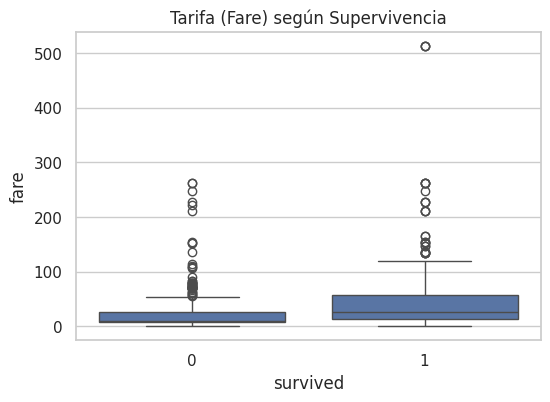

In [7]:
# --- Supervivencia por sexo ---
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='sex', hue='survived')
plt.title('Supervivencia por Sexo')
plt.show()

# --- Supervivencia por clase ---
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x='class', hue='survived')
plt.title('Supervivencia por Clase')
plt.show()

# --- Edad vs Supervivencia ---
plt.figure(figsize=(6,4))
sns.boxplot(data=df_clean, x='survived', y='age')
plt.title('Edad según Supervivencia')
plt.show()

# --- Tarifa vs Supervivencia ---
plt.figure(figsize=(6,4))
sns.boxplot(data=df_clean, x='survived', y='fare')
plt.title('Tarifa (Fare) según Supervivencia')
plt.show()


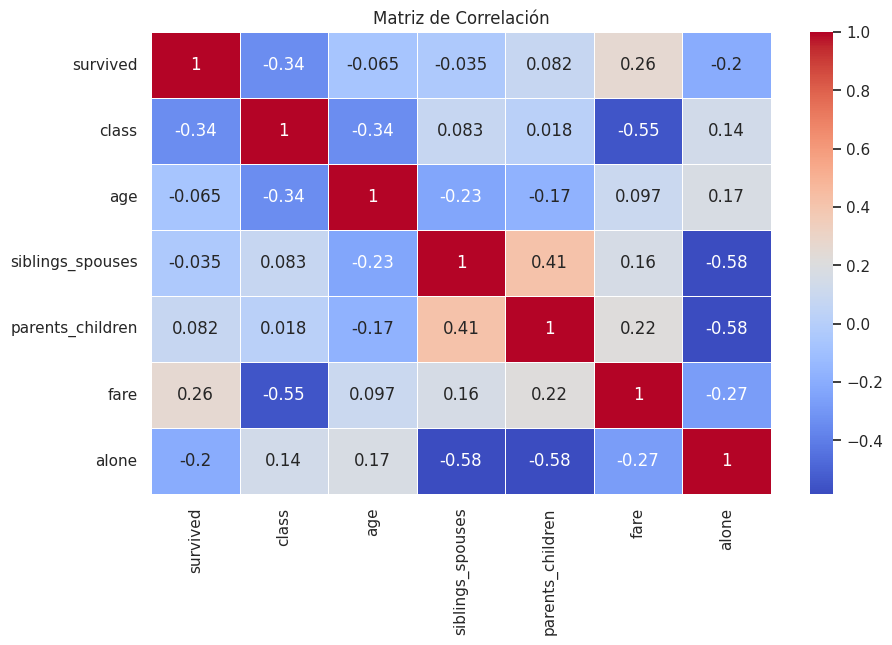

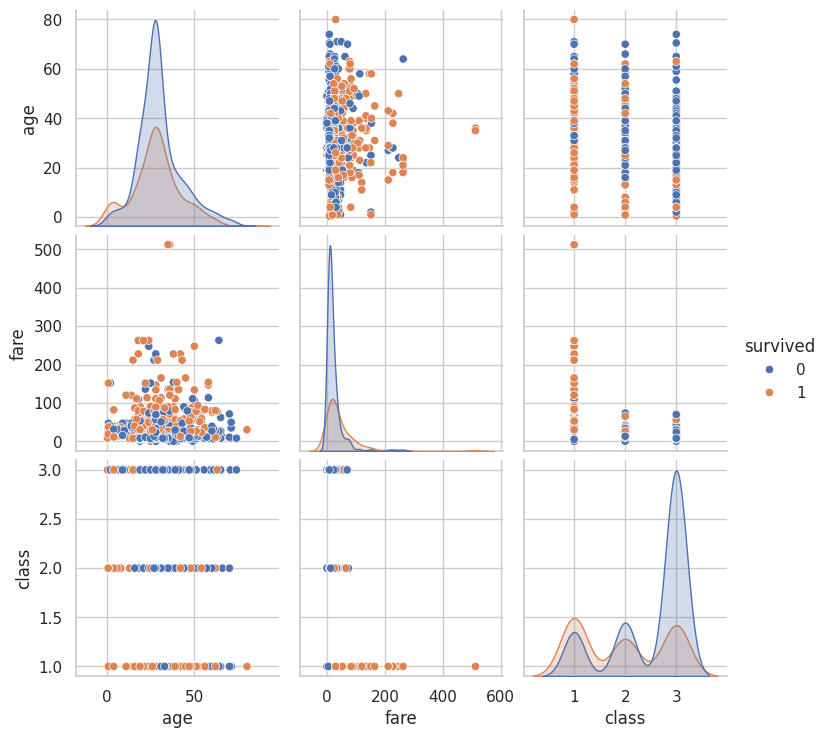

In [8]:
# --- Matriz de correlación ---
plt.figure(figsize=(10,6))
corr = df_clean.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

# --- Pairplot (relaciones múltiples) ---
sns.pairplot(df_clean[['survived', 'age', 'fare', 'class']], hue='survived')
plt.show()


In [9]:
# --- Conclusiones del análisis ---

print("""
CONCLUSIONES DEL ANÁLISIS DEL TITANIC

1. El sexo fue un factor determinante:
   - Las mujeres tuvieron una probabilidad de supervivencia mucho mayor que los hombres.

2. La clase social influyó fuertemente:
   - Los pasajeros de 1ª clase sobrevivieron más.
   - Los de 3ª clase fueron los que menos sobrevivieron.

3. La edad mostró patrones interesantes:
   - Los sobrevivientes tendieron a ser más jóvenes.
   - Los niños tuvieron mayores tasas de supervivencia.

4. La tarifa (fare) también se relacionó con la supervivencia:
   - Pasajeros que pagaron tarifas más altas tuvieron más probabilidades de sobrevivir.

5. Las correlaciones confirman estos patrones:
   - Sexo, clase y tarifa son las variables más relacionadas con la supervivencia.

Este análisis permite comprender qué factores influyeron en la supervivencia
y demuestra el uso de técnicas de EDA con Python, seaborn y visualizaciones estadísticas.
""")



CONCLUSIONES DEL ANÁLISIS DEL TITANIC

1. El sexo fue un factor determinante:
   - Las mujeres tuvieron una probabilidad de supervivencia mucho mayor que los hombres.

2. La clase social influyó fuertemente:
   - Los pasajeros de 1ª clase sobrevivieron más.
   - Los de 3ª clase fueron los que menos sobrevivieron.

3. La edad mostró patrones interesantes:
   - Los sobrevivientes tendieron a ser más jóvenes.
   - Los niños tuvieron mayores tasas de supervivencia.

4. La tarifa (fare) también se relacionó con la supervivencia:
   - Pasajeros que pagaron tarifas más altas tuvieron más probabilidades de sobrevivir.

5. Las correlaciones confirman estos patrones:
   - Sexo, clase y tarifa son las variables más relacionadas con la supervivencia.

Este análisis permite comprender qué factores influyeron en la supervivencia
y demuestra el uso de técnicas de EDA con Python, seaborn y visualizaciones estadísticas.

